# Кластеризация землетрясений (DBSCAN)

**Датасет:** [Significant Earthquakes, 1965-2016](https://www.kaggle.com/datasets/usgs/earthquake-database) - 23412 землетрясений с магнитудой 5.5+, координаты, глубина, магнитуда
**Задача:** кластеризация сейсмических зон по географическому положению методом DBSCAN

## 1. Краткая теория

**DBSCAN** группирует точки по плотности: ядровые точки (>= `min_samples` соседей в радиусе `eps`) формируют кластеры, изолированные точки - шум. Не требует указания числа кластеров, находит кластеры произвольной формы, устойчив к выбросам.

Точка $x$ - ядровая, если $|N_\varepsilon(x)| \geq \text{min\_samples}$, где $N_\varepsilon(x) = \{x' \in D : d(x, x') \leq \varepsilon\}$.

Подробная теория - в [README.md](README.md).

## 2. Загрузка данных

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import kagglehub

path = kagglehub.dataset_download('usgs/earthquake-database')
df = pd.read_csv(f'{path}/database.csv')

In [2]:
print(f'Размер: {df.shape[0]} записей, {df.shape[1]} столбцов')
df.head()

Размер: 23412 записей, 21 столбцов


,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

## 3. Первичный анализ

In [4]:
df[['Latitude', 'Longitude', 'Depth', 'Magnitude']].describe()

,Latitude,Longitude,Depth,Magnitude
count,23412.000000,23412.000000,23412.000000,23412.000000
mean,1.679033,39.639961,70.767911,5.882531
std,30.113183,125.511959,122.651898,0.423066
min,-77.080000,-179.997000,-1.100000,5.500000
25%,-18.653000,-76.349750,14.522500,5.600000
50%,-3.568500,103.982000,33.000000,5.700000
75%,26.190750,145.026250,54.000000,6.000000
max,86.005000,179.998000,700.000000,9.100000


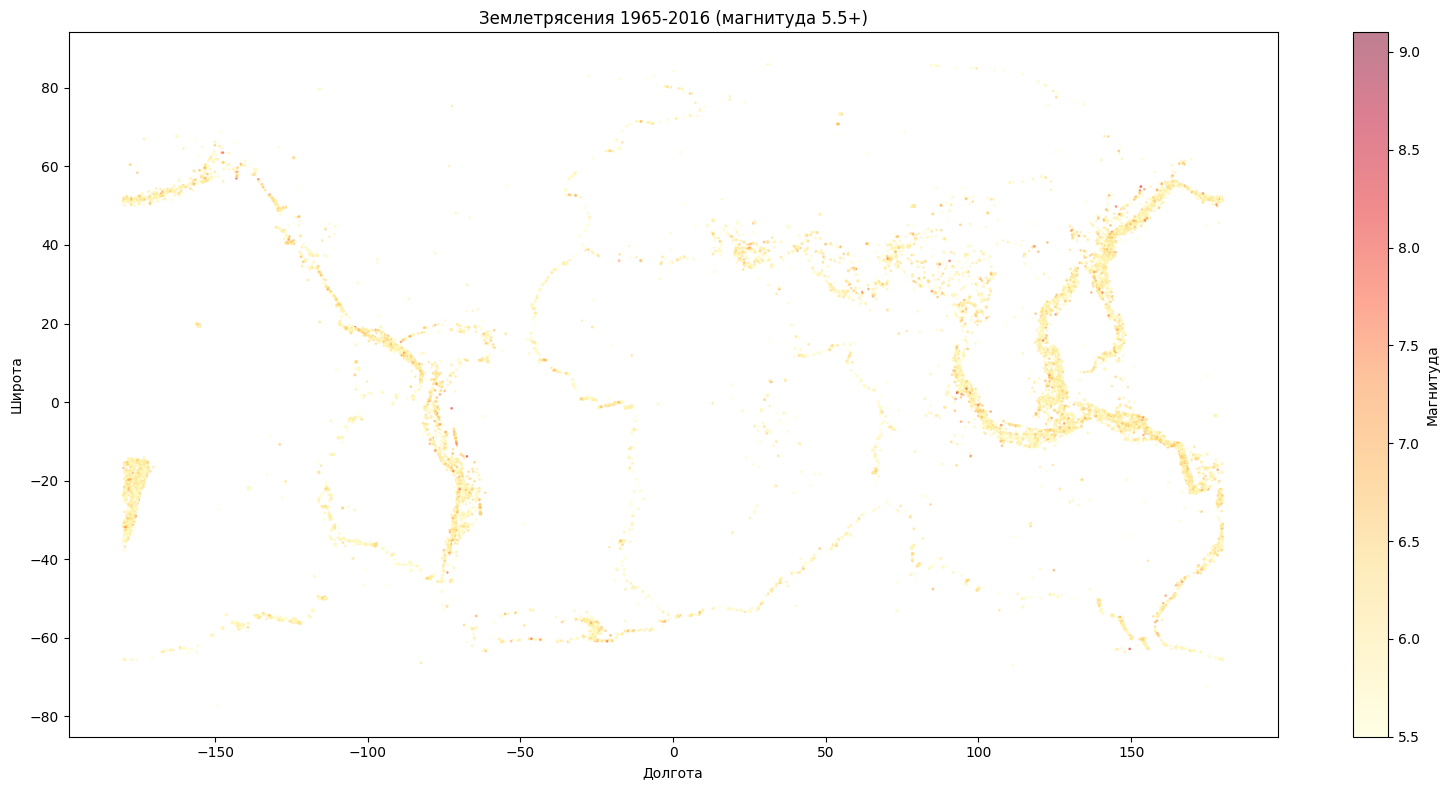

Типы событий: {'Earthquake': 23232, 'Nuclear Explosion': 175, 'Explosion': 4, 'Rock Burst': 1}


In [5]:
# карта всех землетрясений
plt.figure(figsize=(16, 8))
scatter = plt.scatter(df['Longitude'], df['Latitude'],
                      c=df['Magnitude'], cmap='YlOrRd',
                      s=1, alpha=0.5)
plt.colorbar(scatter, label='Магнитуда')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title('Землетрясения 1965-2016 (магнитуда 5.5+)')
plt.tight_layout()
plt.show()

print(f'Типы событий: {df["Type"].value_counts().to_dict()}')

Землетрясения чётко концентрируются вдоль тектонических границ: Тихоокеанское огненное кольцо, Средиземноморско-Гималайский пояс, Срединно-Атлантический хребет. Идеальная задача для DBSCAN - кластеры вытянутой формы с шумовыми точками вне основных зон.

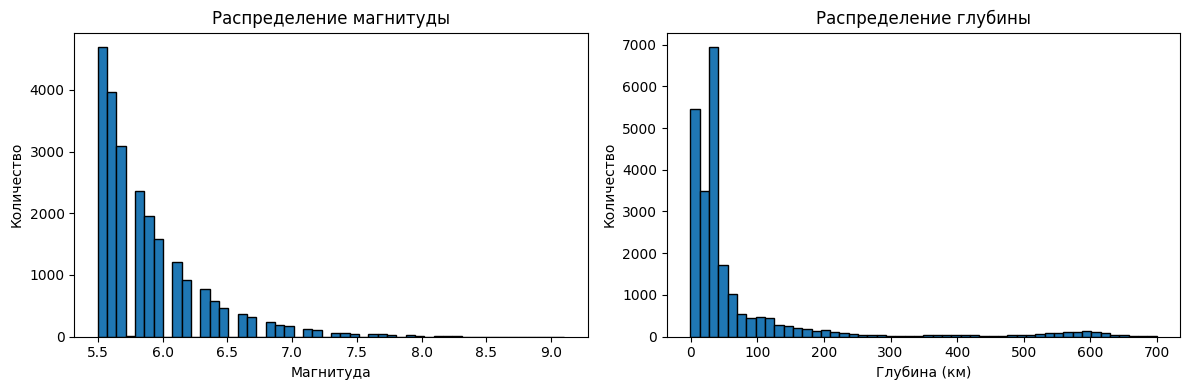

Магнитуда: медиана=5.7, макс=9.1
Глубина: медиана=33 км, макс=700 км


In [6]:
# распределение магнитуды и глубины
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Magnitude'], bins=50, edgecolor='black')
axes[0].set_xlabel('Магнитуда')
axes[0].set_ylabel('Количество')
axes[0].set_title('Распределение магнитуды')

axes[1].hist(df['Depth'], bins=50, edgecolor='black')
axes[1].set_xlabel('Глубина (км)')
axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение глубины')

plt.tight_layout()
plt.show()

print(f'Магнитуда: медиана={df["Magnitude"].median():.1f}, макс={df["Magnitude"].max():.1f}')
print(f'Глубина: медиана={df["Depth"].median():.0f} км, макс={df["Depth"].max():.0f} км')

Большинство землетрясений имеют магнитуду 5.5-6.0 (медиана 5.7, максимум 9.1) и расположены на малой глубине (медиана 33 км). Глубокофокусные землетрясения (до 700 км) приурочены к зонам субдукции.

## 4. Предобработка

In [7]:
# оставляем только землетрясения (без ядерных взрывов)
df_eq = df[df['Type'] == 'Earthquake'].copy()
print(f'Землетрясений: {len(df_eq)}')

# для кластеризации используем координаты
coords = df_eq[['Latitude', 'Longitude']].values

# масштабирование
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

print(f'Признаков: {coords_scaled.shape[1]}')
print(f'Диапазон широты: [{df_eq["Latitude"].min():.1f}, {df_eq["Latitude"].max():.1f}]')
print(f'Диапазон долготы: [{df_eq["Longitude"].min():.1f}, {df_eq["Longitude"].max():.1f}]')

Землетрясений: 23232
Признаков: 2
Диапазон широты: [-77.1, 86.0]
Диапазон долготы: [-180.0, 180.0]


## 5. Кластеризация

### Подбор eps методом k-расстояний

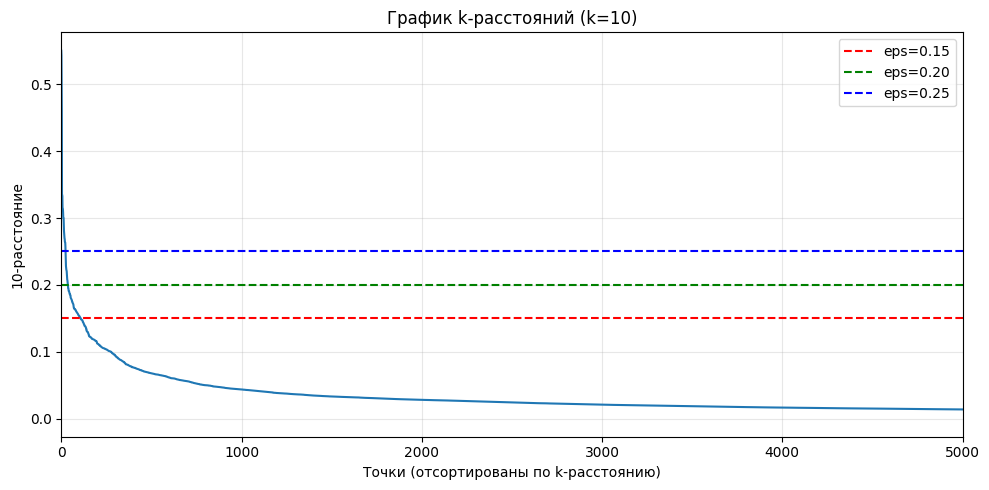

In [8]:
# метод k-расстояний для подбора eps
k = 10  # min_samples - 1
nn = NearestNeighbors(n_neighbors=k)
nn.fit(coords_scaled)
distances, _ = nn.kneighbors(coords_scaled)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.xlabel('Точки (отсортированы по k-расстоянию)')
plt.ylabel(f'{k}-расстояние')
plt.title(f'График k-расстояний (k={k})')
plt.axhline(y=0.15, color='r', linestyle='--', label='eps=0.15')
plt.axhline(y=0.20, color='g', linestyle='--', label='eps=0.20')
plt.axhline(y=0.25, color='b', linestyle='--', label='eps=0.25')
plt.legend()
plt.xlim(0, 5000)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Колено графика k-расстояний указывает на eps в районе 0.15-0.25. Попробуем несколько значений.

### Перебор параметров

In [9]:
# перебор eps и min_samples
param_results = []

for eps in [0.10, 0.15, 0.20, 0.25, 0.30]:
    for min_s in [5, 10, 15, 20]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(coords_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100

        sil = -1
        if n_clusters >= 2 and n_clusters < len(labels) - 1:
            mask = labels != -1
            if len(set(labels[mask])) >= 2:
                sil = silhouette_score(coords_scaled[mask], labels[mask],
                                       sample_size=min(5000, mask.sum()))

        param_results.append({
            'eps': eps, 'min_samples': min_s,
            'Кластеров': n_clusters, 'Шум (%)': round(noise_pct, 1),
            'Silhouette': round(sil, 4)
        })

results_df = pd.DataFrame(param_results)
print(results_df.to_string(index=False))

 eps  min_samples  Кластеров  Шум (%)  Silhouette
0.10            5         16      0.3     -0.4443
0.10           10         15      0.7     -0.3841
0.10           15         15      1.0     -0.2433
0.10           20         17      1.5     -0.1647
0.15            5          5      0.1      0.1455
0.15           10          7      0.2     -0.3340
0.15           15          6      0.5     -0.0922
0.15           20          7      0.6     -0.1047
0.20            5          4      0.1      0.1359
0.20           10          4      0.1      0.1352
0.20           15          4      0.1      0.1350
0.20           20          3      0.2      0.2057
0.25            5          3      0.0      0.0171
0.25           10          3      0.0      0.0223
0.25           15          3      0.0      0.0262
0.25           20          3      0.1      0.0148
0.30            5          2      0.0      0.1013
0.30           10          2      0.0      0.1029
0.30           15          2      0.0      0.1079


При eps=0.10 слишком много мелких кластеров (15-17) с отрицательным Silhouette. При eps=0.20-0.25 формируются 3-4 осмысленных кластера. Лучший Silhouette=0.207 при eps=0.20, min_samples=20.

In [10]:
# выбираем оптимальные параметры по silhouette
best_row = results_df[results_df['Silhouette'] > 0].sort_values('Silhouette', ascending=False).iloc[0]
best_eps = best_row['eps']
best_min_samples = int(best_row['min_samples'])

print(f'Лучшие параметры: eps={best_eps}, min_samples={best_min_samples}')
print(f'Кластеров: {int(best_row["Кластеров"])}, Шум: {best_row["Шум (%)"]:.1f}%, Silhouette: {best_row["Silhouette"]:.4f}')

Лучшие параметры: eps=0.2, min_samples=20
Кластеров: 3, Шум: 0.2%, Silhouette: 0.2057


In [11]:
# финальная кластеризация
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df_eq['cluster'] = dbscan.fit_predict(coords_scaled)

n_clusters = df_eq['cluster'].nunique() - (1 if -1 in df_eq['cluster'].values else 0)
n_noise = (df_eq['cluster'] == -1).sum()

print(f'Кластеров: {n_clusters}')
print(f'Шумовых точек: {n_noise} ({n_noise/len(df_eq)*100:.1f}%)')
print(f'\nРазмеры кластеров:')
cluster_sizes = df_eq[df_eq['cluster'] != -1]['cluster'].value_counts().sort_index()
for c, size in cluster_sizes.items():
    print(f'  Кластер {c}: {size} точек')

Кластеров: 3
Шумовых точек: 54 (0.2%)

Размеры кластеров:
  Кластер 0: 20576 точек
  Кластер 1: 2578 точек
  Кластер 2: 24 точек


## 6. Оценка качества

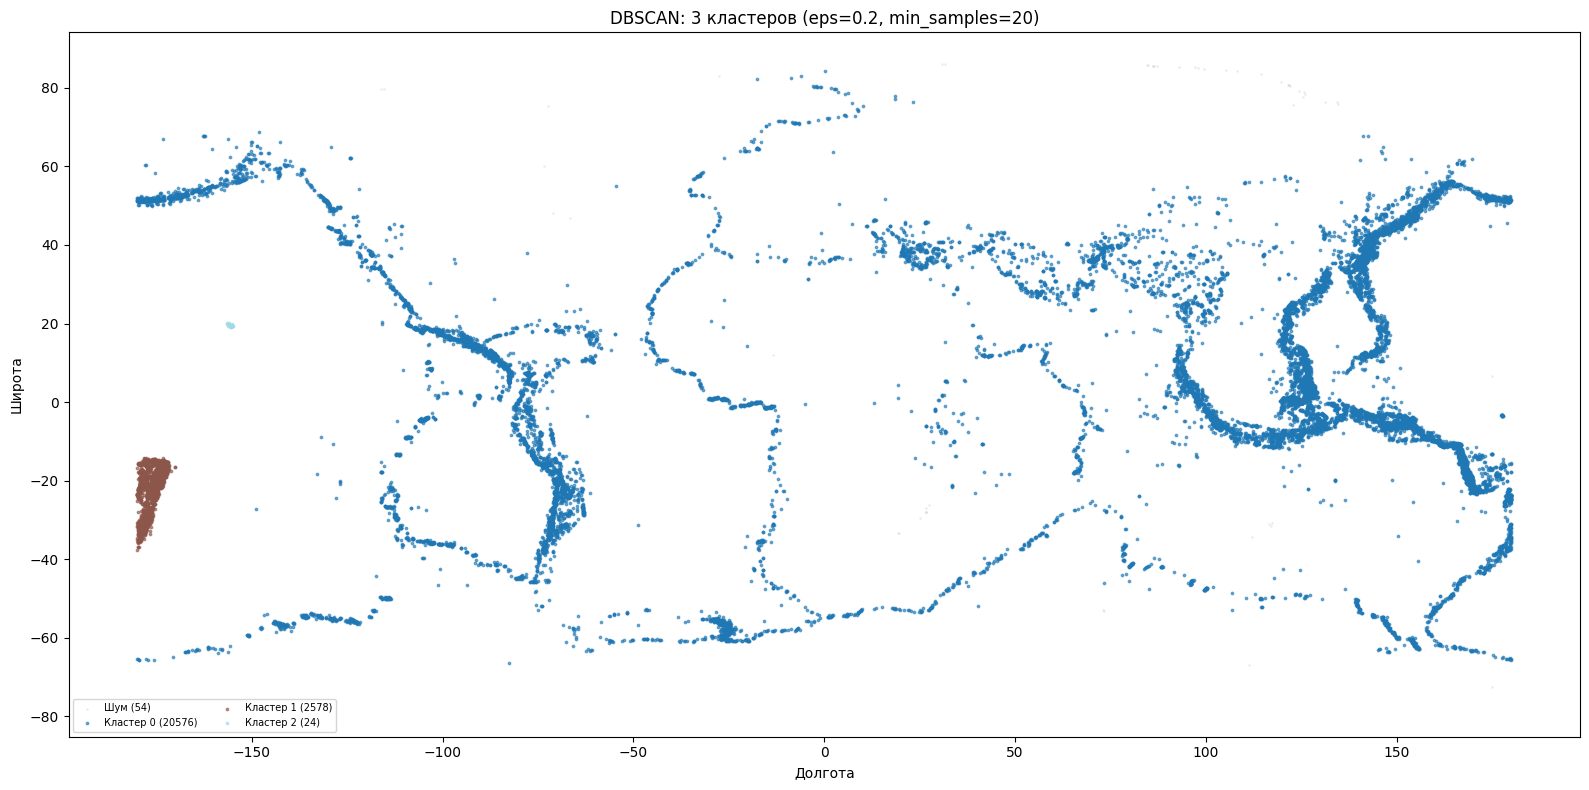

In [12]:
# визуализация кластеров на карте
plt.figure(figsize=(16, 8))

# шумовые точки
noise = df_eq[df_eq['cluster'] == -1]
plt.scatter(noise['Longitude'], noise['Latitude'],
            c='lightgray', s=1, alpha=0.3, label=f'Шум ({len(noise)})')

# кластеры
clustered = df_eq[df_eq['cluster'] != -1]
colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))
for i, (c, group) in enumerate(clustered.groupby('cluster')):
    plt.scatter(group['Longitude'], group['Latitude'],
                c=[colors[i % len(colors)]], s=3, alpha=0.6,
                label=f'Кластер {c} ({len(group)})')

plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title(f'DBSCAN: {n_clusters} кластеров (eps={best_eps}, min_samples={best_min_samples})')
if n_clusters <= 15:
    plt.legend(loc='lower left', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

DBSCAN выделил 3 кластера: основной (20576 точек) - Евразийско-Тихоокеанский пояс, второй (2578) - зона Тонга-Кермадек в юго-западной части Тихого океана, третий (24) - Гавайская горячая точка. Шум составил всего 0.2% (54 точки) - одиночные землетрясения вдали от основных зон.

In [13]:
# статистика по кластерам
stats = df_eq[df_eq['cluster'] != -1].groupby('cluster').agg(
    Количество=('Latitude', 'count'),
    Ср_магнитуда=('Magnitude', 'mean'),
    Макс_магнитуда=('Magnitude', 'max'),
    Ср_глубина=('Depth', 'mean'),
    Ср_широта=('Latitude', 'mean'),
    Ср_долгота=('Longitude', 'mean')
).round(2)

print(stats.to_string())

         Количество  Ср_магнитуда  Макс_магнитуда  Ср_глубина  Ср_широта  Ср_долгота
cluster                                                                             
0             20576          5.89             9.1       60.08       4.23       67.00
1              2578          5.83             8.1      162.70     -22.30     -176.48
2                24          5.91             7.1       14.27      19.47     -155.46


Кластер 1 (Тонга-Кермадек) отличается наибольшей средней глубиной (162.7 км) - активная зона субдукции. Кластер 0 (основной) имеет среднюю глубину 60 км. Кластер 2 (Гавайи) - мелкофокусный (14.3 км), типично для горячих точек.

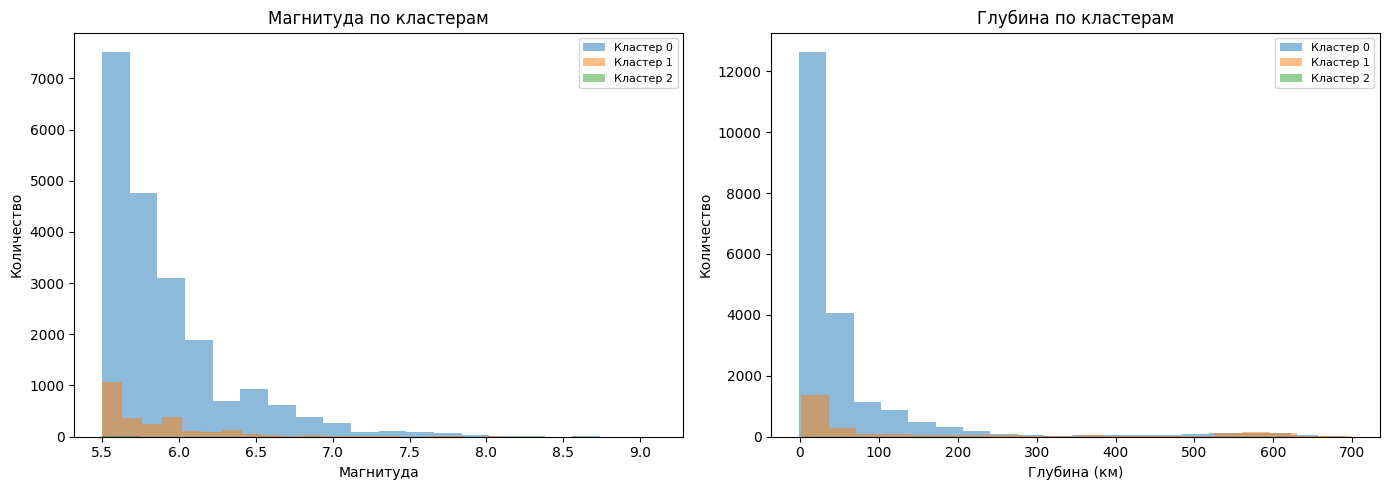

In [14]:
# сравнение магнитуды и глубины по кластерам
top_clusters = cluster_sizes.nlargest(5).index.tolist()
df_top = df_eq[df_eq['cluster'].isin(top_clusters)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c in top_clusters:
    data = df_top[df_top['cluster'] == c]
    axes[0].hist(data['Magnitude'], bins=20, alpha=0.5, label=f'Кластер {c}')
    axes[1].hist(data['Depth'], bins=20, alpha=0.5, label=f'Кластер {c}')

axes[0].set_xlabel('Магнитуда')
axes[0].set_ylabel('Количество')
axes[0].set_title('Магнитуда по кластерам')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Глубина (км)')
axes[1].set_ylabel('Количество')
axes[1].set_title('Глубина по кластерам')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Кластеры в зоне субдукции (западная часть Тихого океана) отличаются большей глубиной землетрясений по сравнению со срединно-океаническими хребтами, где землетрясения преимущественно мелкофокусные.

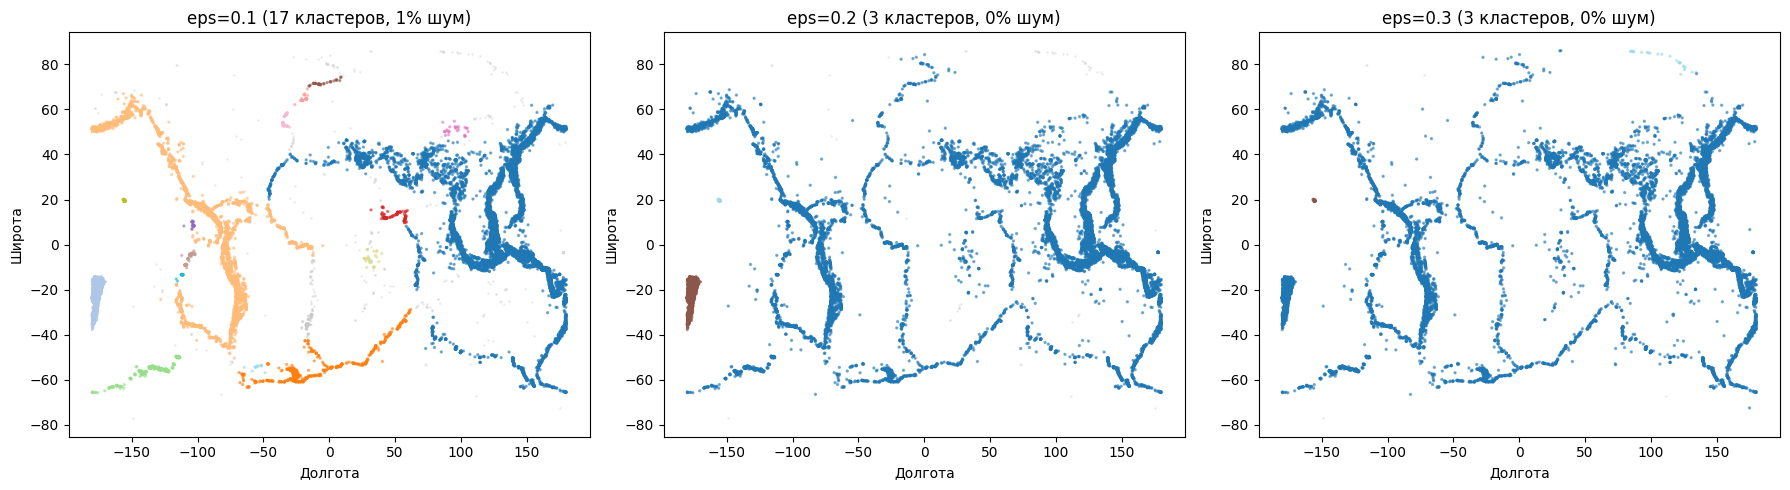

In [15]:
# влияние eps на результат
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, eps_val in zip(axes, [0.10, best_eps, 0.30]):
    db = DBSCAN(eps=eps_val, min_samples=best_min_samples)
    labels = db.fit_predict(coords_scaled)
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    n_ns = (labels == -1).sum()

    noise_mask = labels == -1
    ax.scatter(df_eq.loc[noise_mask, 'Longitude'], df_eq.loc[noise_mask, 'Latitude'],
               c='lightgray', s=1, alpha=0.3)
    if not noise_mask.all():
        ax.scatter(df_eq.loc[~noise_mask, 'Longitude'], df_eq.loc[~noise_mask, 'Latitude'],
                   c=labels[~noise_mask], cmap='tab20', s=2, alpha=0.5)
    ax.set_title(f'eps={eps_val} ({n_cl} кластеров, {n_ns/len(labels)*100:.0f}% шум)')
    ax.set_xlabel('Долгота')
    ax.set_ylabel('Широта')

plt.tight_layout()
plt.show()

При малом eps (0.10) кластеры дробятся на мелкие фрагменты, большая часть точек - шум. При большом eps (0.30) кластеры сливаются в один-два гигантских. Оптимальное значение даёт осмысленное разделение на сейсмические зоны.